In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

## run simulations


In [2]:
import subprocess
import os

efficiency_values = [0, 0.2, 0.4, 0.6, 0.8, 1.0]

cmd = ["python", "/Users/ljb80/Projects/perturbo/src/perturbo/_jax_module.py"]
base_args = str.split(
    "--n_control 1000 --n_perturbed 400 --n_guides 2 --log2_fc -0.5 --gene_mean 2.0 --gene_disp 10.0 "
)

for efficiency in efficiency_values:
    output_dir = f"data/run_efficiency_{efficiency:0.1f}"
    if os.path.isdir(output_dir):
        continue
    args_new = ["--efficiency", str(efficiency), "1.0", "--output_dir", output_dir]
    args = base_args + args_new
    subprocess.run(cmd + args)

## load results


In [3]:
# for k in ["log2_fold_change", "mean", "dispersion"]:
# k = "log2_fold_change"


def get_simulation_df(data_dir, k):
    """Read the MCMC and SVI posterior samples from data_dir and return a combined DataFrame for the key k."""
    mcmc_file = f"{data_dir}/mcmc.npz"
    svi_file = f"{data_dir}/svi.npz"
    mcmc_npz = np.load(mcmc_file)
    svi_npz = np.load(svi_file)

    mcmc_df = pd.DataFrame({k: mcmc_npz[k].squeeze(), "method": "MCMC"})
    svi_df = pd.DataFrame({k: svi_npz[k].squeeze(), "method": "SVI"})
    df = pd.concat((mcmc_df, svi_df))
    return df


def get_efficiency_df(data_dir):
    """Read the MCMC and SVI posterior samples from data_dir and return a combined DataFrame for the key k."""
    mcmc_file = f"{data_dir}/mcmc.npz"
    svi_file = f"{data_dir}/svi.npz"
    mcmc_npz = np.load(mcmc_file)
    svi_npz = np.load(svi_file)

    mcmc_data = mcmc_npz["efficiency"].squeeze()
    n_guides = mcmc_data.shape[1]
    guide_names = [f"guide_{i+1}" for i in range(n_guides)]
    mcmc_df = pd.DataFrame(mcmc_npz["efficiency"].squeeze(), columns=guide_names).assign(method="MCMC")
    svi_df = pd.DataFrame(svi_npz["efficiency"].squeeze(), columns=guide_names).assign(method="SVI")
    # mcmc_df = pd.DataFramepd.DataFrame({k: mcmc_npz[k].squeeze(), "method": "MCMC"})
    # svi_df = pd.DataFrame({k: svi_npz[k].squeeze(), "method": "SVI"})
    df = pd.concat((mcmc_df, svi_df))
    return df


get_efficiency_df("data/run_efficiency_1.0/")

,guide_1,guide_2,method
0,0.686051,0.973917,MCMC
1,0.964364,0.989001,MCMC
2,0.905955,0.903415,MCMC
3,0.873573,0.903789,MCMC
4,0.750663,0.983046,MCMC
...,...,...,...
995,0.869223,0.931082,SVI
996,0.679072,0.808078,SVI
997,0.856263,0.979759,SVI
998,0.853268,0.910699,SVI


In [4]:
dfs = []
for efficiency in efficiency_values:
    output_dir = f"data/run_efficiency_{efficiency:0.1f}"
    lfc_df = get_simulation_df(output_dir, "log2_fold_change")
    efficiency_df = get_efficiency_df(output_dir)
    combined_df = pd.concat([lfc_df["log2_fold_change"], efficiency_df], axis=1).assign(efficiency=efficiency)
    dfs.append(combined_df)
lfc_all_df = pd.concat(dfs)

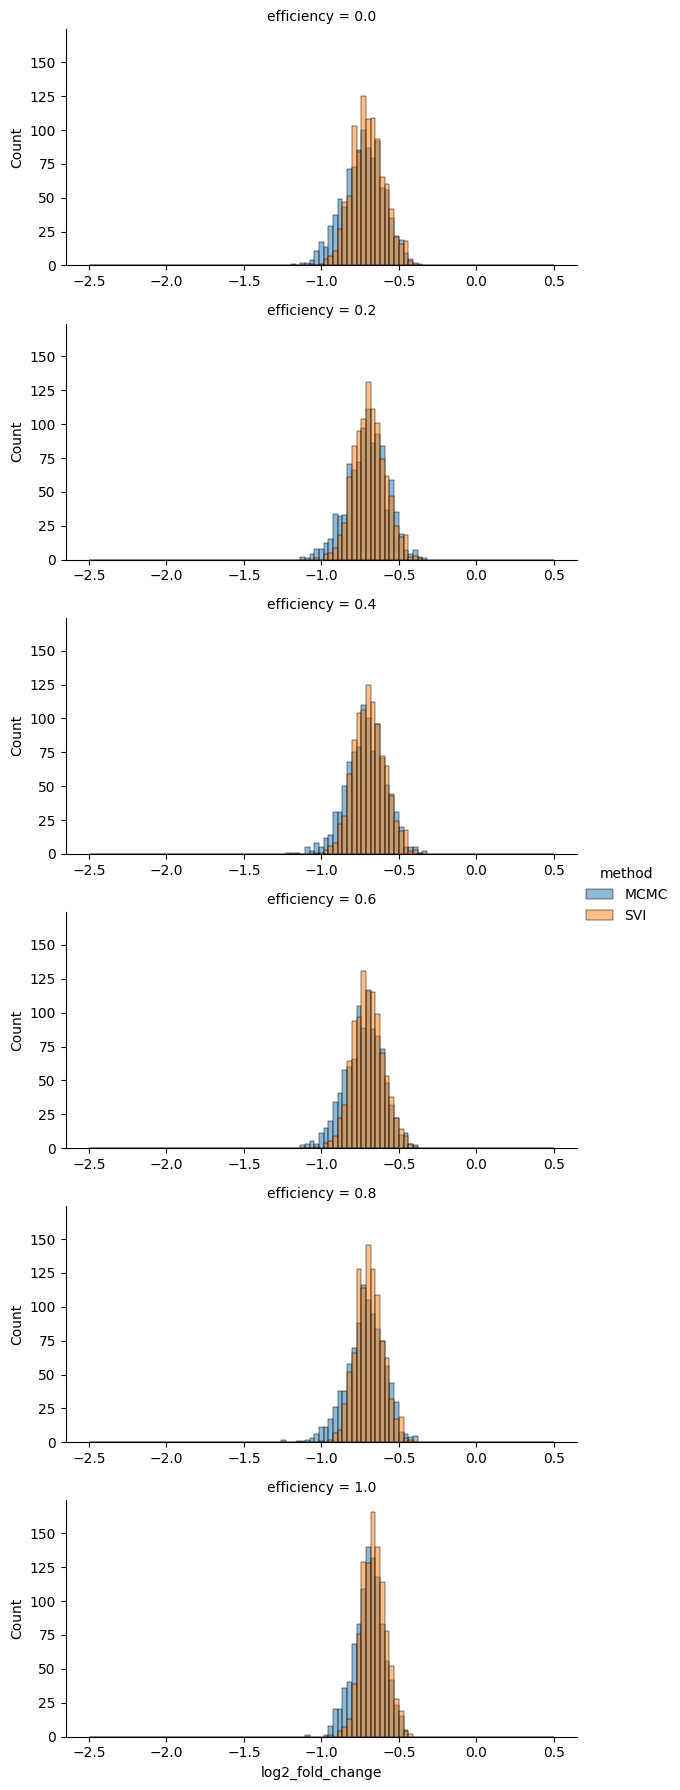

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

n_bins = 100

g = sns.FacetGrid(lfc_all_df, row="efficiency", hue="method", height=3, aspect=2, sharex=False)
g.map(sns.histplot, "log2_fold_change", alpha=0.5, bins=np.linspace(-2.5, 0.5, n_bins))
# Add a legend
g.add_legend()

plt.show()

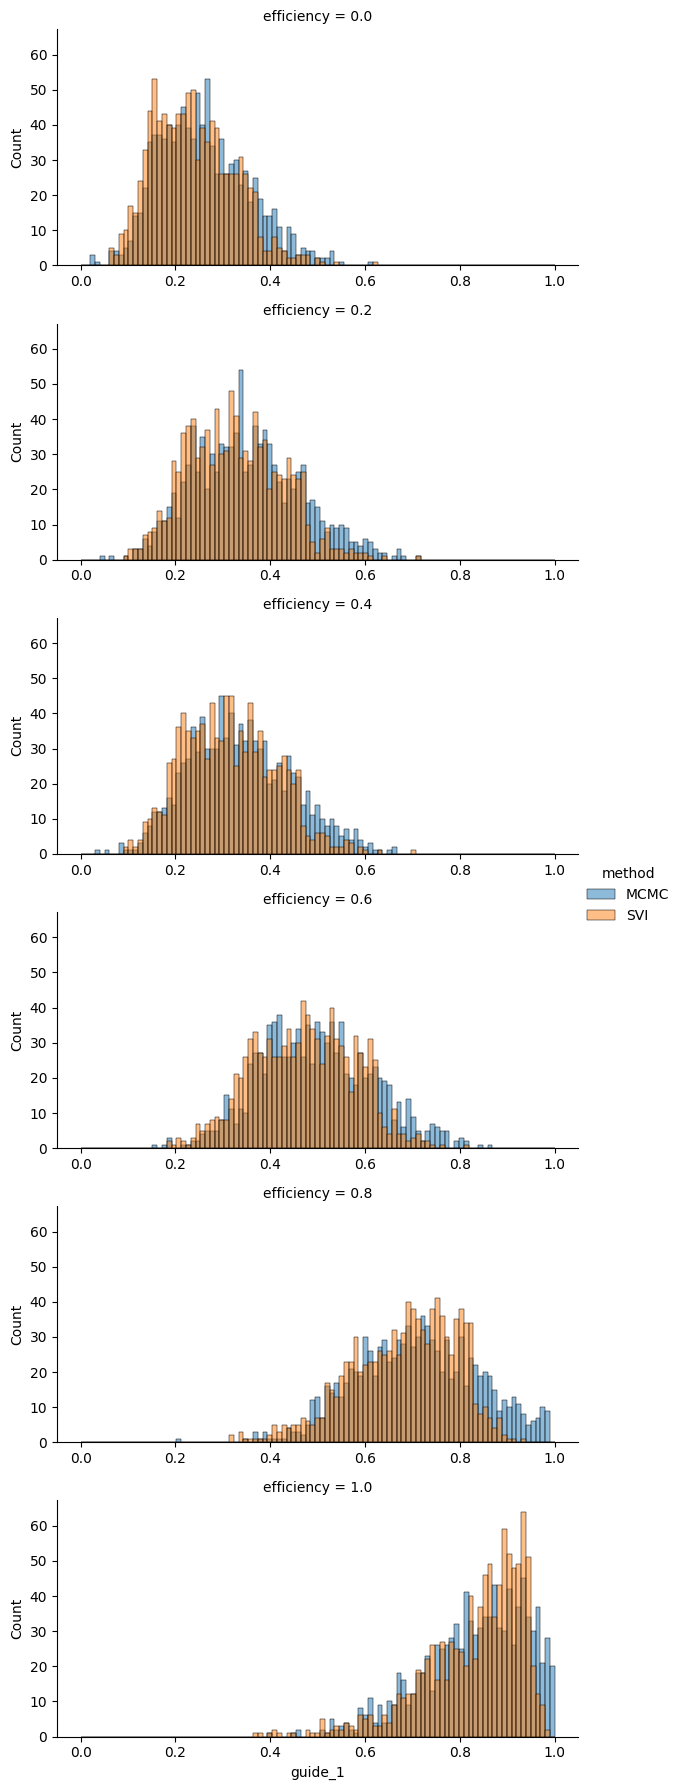

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

n_bins = 100

g = sns.FacetGrid(lfc_all_df, row="efficiency", hue="method", height=3, aspect=2, sharex=False)
g.map(sns.histplot, "guide_1", alpha=0.5, bins=np.linspace(0, 1, n_bins))
# Add a legend
g.add_legend()

plt.show()

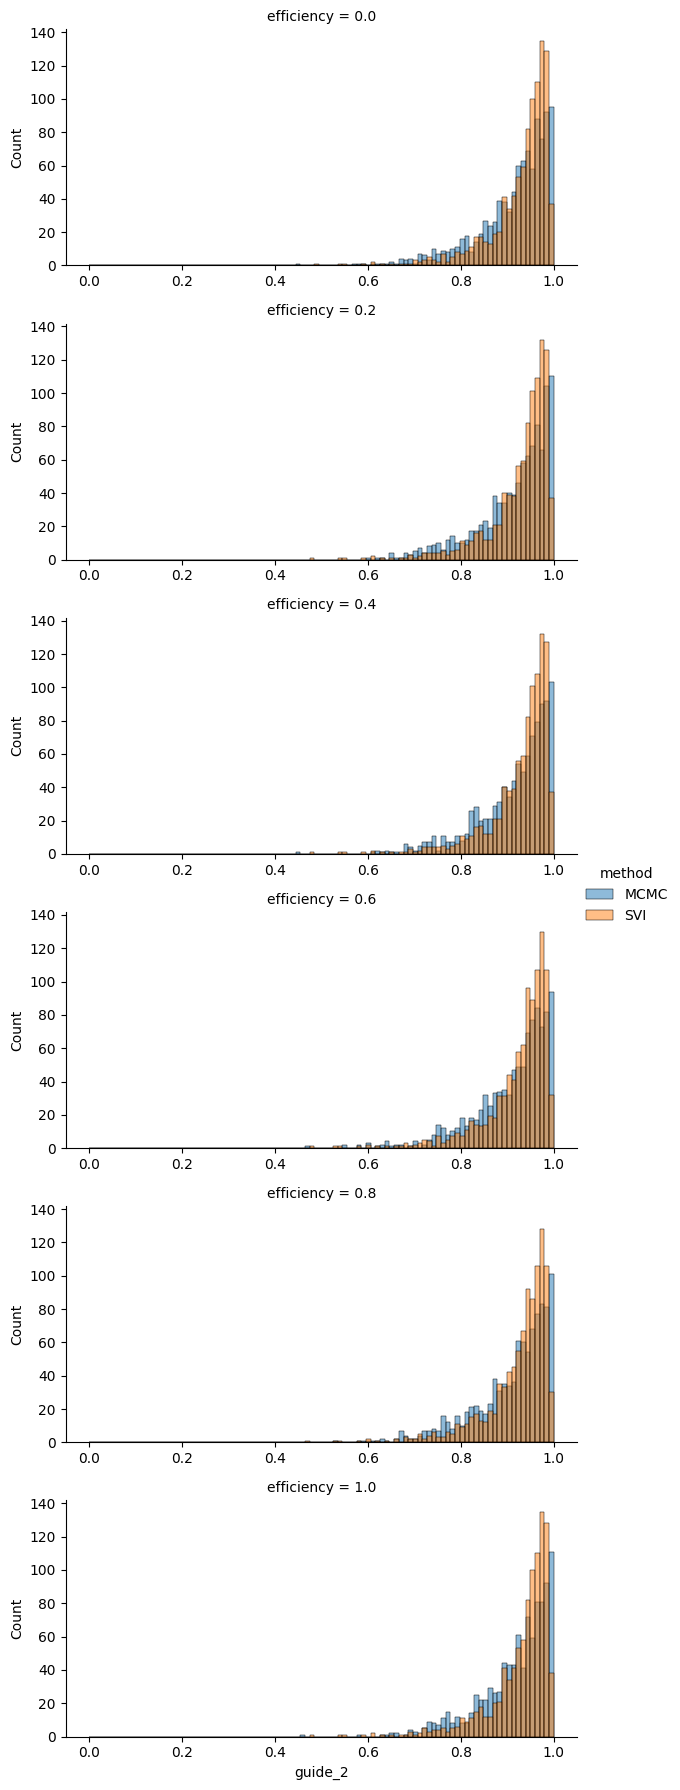

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

n_bins = 100

g = sns.FacetGrid(lfc_all_df, row="efficiency", hue="method", height=3, aspect=2, sharex=False)
g.map(sns.histplot, "guide_2", alpha=0.5, bins=np.linspace(0, 1, n_bins))
# Add a legend
g.add_legend()

plt.show()

In [8]:
lfc_all_df = lfc_all_df.assign(scaled_lfc=lambda x: x["log2_fold_change"] * x["guide_2"])
lfc_all_df

,log2_fold_change,guide_1,guide_2,method,efficiency,scaled_lfc
0,-0.621902,0.167799,0.993726,MCMC,0.0,-0.618001
1,-0.614806,0.395676,0.997673,MCMC,0.0,-0.613375
2,-0.900705,0.125129,0.962852,MCMC,0.0,-0.867246
3,-0.801561,0.117440,0.954839,MCMC,0.0,-0.765361
4,-0.743765,0.120162,0.983121,MCMC,0.0,-0.731211
...,...,...,...,...,...,...
995,-0.734843,0.869223,0.931082,SVI,1.0,-0.684200
996,-0.702382,0.679072,0.808078,SVI,1.0,-0.567579
997,-0.734081,0.856263,0.979759,SVI,1.0,-0.719223
998,-0.729136,0.853268,0.910699,SVI,1.0,-0.664024


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

n_bins = 100
lfc_all_df = lfc_all_df.assign(scaled_lfc_1=lambda x: x["log2_fold_change"] * x["guide_1"], scaled_lfc_2=lambda x: x["log2_fold_change"] * x["guide_2"])
lfc_all_df


,log2_fold_change,guide_1,guide_2,method,efficiency,scaled_lfc,scaled_lfc_1,scaled_lfc_2
0,-0.621902,0.167799,0.993726,MCMC,0.0,-0.618001,-0.104354,-0.618001
1,-0.614806,0.395676,0.997673,MCMC,0.0,-0.613375,-0.243264,-0.613375
2,-0.900705,0.125129,0.962852,MCMC,0.0,-0.867246,-0.112704,-0.867246
3,-0.801561,0.117440,0.954839,MCMC,0.0,-0.765361,-0.094136,-0.765361
4,-0.743765,0.120162,0.983121,MCMC,0.0,-0.731211,-0.089372,-0.731211
...,...,...,...,...,...,...,...,...
995,-0.734843,0.869223,0.931082,SVI,1.0,-0.684200,-0.638743,-0.684200
996,-0.702382,0.679072,0.808078,SVI,1.0,-0.567579,-0.476968,-0.567579
997,-0.734081,0.856263,0.979759,SVI,1.0,-0.719223,-0.628566,-0.719223
998,-0.729136,0.853268,0.910699,SVI,1.0,-0.664024,-0.622149,-0.664024


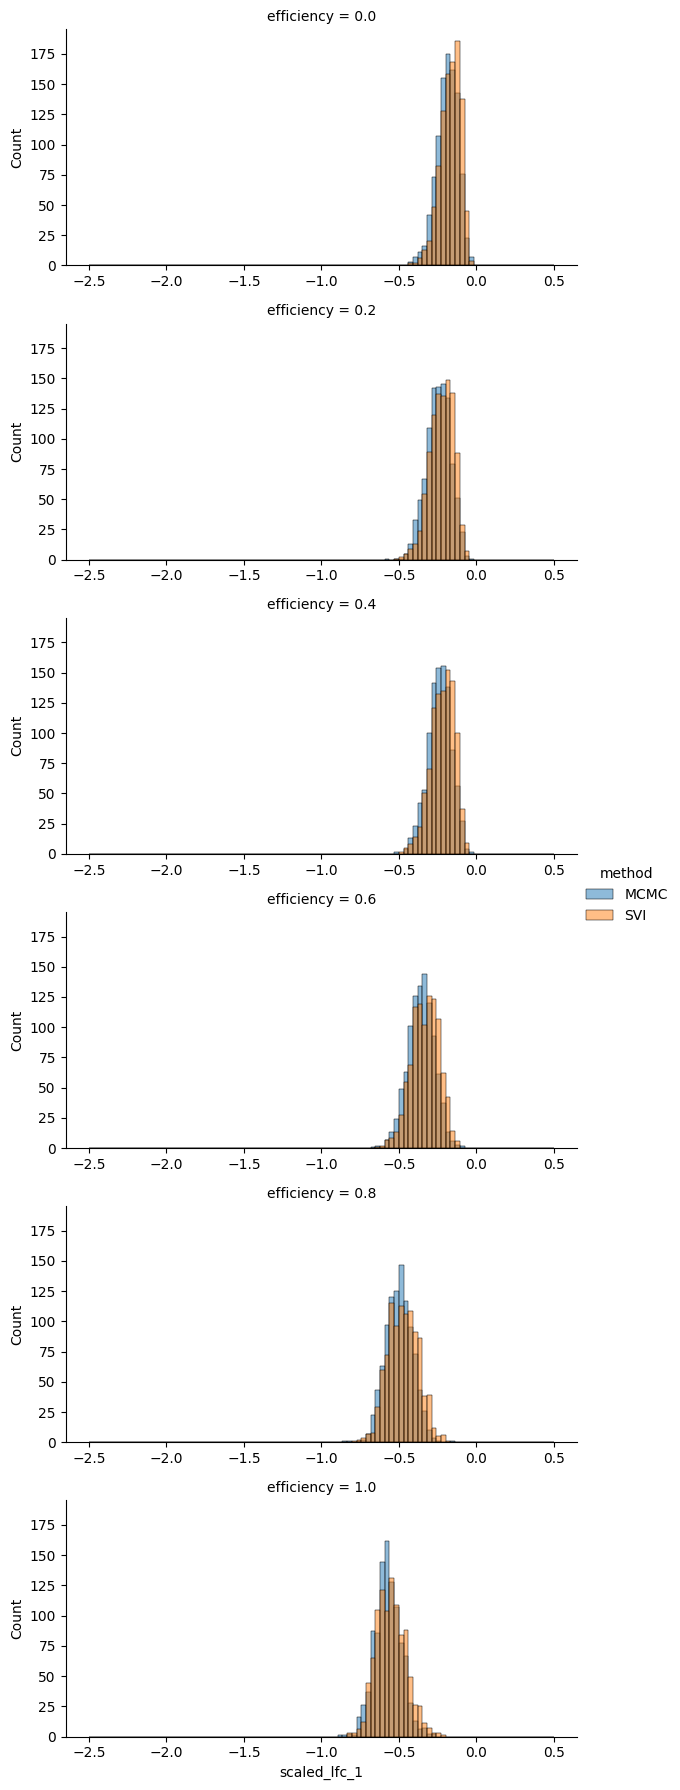

In [10]:
g = sns.FacetGrid(lfc_all_df, row="efficiency", hue="method", height=3, aspect=2, sharex=False)
g.map(sns.histplot, "scaled_lfc_1", alpha=0.5, bins=np.linspace(-2.5, 0.5, n_bins))
# Add a legend
g.add_legend()

plt.show()